## IQM Resonance Example Notebook
In order to get started, make sure you have the appropriate packages installed. As prerequisite, you need to have **Python 3.11** or above and pip installed on your system.

You have chosen IQM Sirius as your quantum computer. The following code snippet also shows how to create an IQM client and connect to this specific device.

Run the cell and enter your IQM Resonance access token when prompted. You can create an access token on the [IQM Resonance profile page](https://resonance.iqm.tech/profile#access-tokens).

In order to install the packages and init the backend to work with IQM hardware in QRISP, run the following cell:

In [12]:
import os, getpass

if not os.environ.get("IQM_TOKEN"):
    os.environ["IQM_TOKEN"] = getpass.getpass("IQM Resonance token: ")

os.environ["IQM_SERVER_URL"] = "https://resonance.iqm.tech"

from iqm.qrisp_iqm import IQMBackend
quantum_computer = IQMBackend(device_instance="garnet")

In [13]:
from qrisp import *

qv = QuantumVariable(3)
h(qv[0])
cx(qv[0], qv[1])
cx(qv[0], qv[2])

circuit = qv.qs.compile()
job = quantum_computer.run_async(circuit)
print(f"Job ID: {job.job_id}")
print(f"Results: {job.result().get_counts()}")

Job ID: 01a06612-4cf6-7080-8d63-759ce40dc477


ERROR:iqm.iqm_server_client.iqm_server_client:Job failed! Error(s):
  iqm-station-control: unknown: Error in stage "circuit_stage" pass "_validate_circuits": Circuit 0: Circuit contains no measurements.


JobFailureError: Job '01a06612-4cf6-7080-8d63-759ce40dc477' terminated with status ERROR.

In [ ]:
# install iqm-client with qrisp extras
!pip install -U "iqm-client==34.0.4" "qrisp[iqm]"
# used for visualization
!pip install matplotlib

from qrisp.interface import IQMBackend

# Set use_timeslot=True if you have booked a timeslot
quantum_computer = IQMBackend(
    api_token = input("IQM Resonance access token"),
    device_instance = "sirius",
    use_timeslot=False)


In [14]:
result = qv.get_measurement(backend=quantum_computer, shots=1000)
print(result)

{'000': 0.513, '111': 0.434, '101': 0.014, '010': 0.012, '110': 0.01, '001': 0.008, '011': 0.007, '100': 0.002}


After successfully installing the required packages and initializing the backend, you can submit the quantum circuit.


In [ ]:
from qrisp import *
from matplotlib import pyplot as plt

# This example creates a GHZ state, replace it with your own code
qv = QuantumVariable(3)
h(qv[0])
cx(qv[0], qv[1])
cx(qv[0], qv[2])

# Execute it on the quantum computing backend
# Transpilation is taken care of automatically
result = qv.get_measurement(backend = quantum_computer)

# Print and plot the result
print(result)

plt.bar(result.keys(), result.values())
plt.xlabel('Measurement outcomes')
plt.ylabel('Probability')
plt.show()

In [15]:
!pip install -q --upgrade pip
!pip install -q iqm-qaoa "qrisp[iqm]" "iqm-client==35.0.2" "numpy<2.5" networkx

In [16]:
import numpy, importlib.metadata as md
print(numpy.__version__, md.version("iqm-client"))
from iqm.qrisp_iqm import IQMBackend
print("ok")

2.4.6 35.0.2
ok


In [17]:
from qrisp import *
from qrisp.grover import tag_state, grovers_alg

from iqm.applications.maxcut import MaxCutInstance, maxcut_generator
from iqm.qaoa.qubo_qaoa import QUBOQAOA
from iqm.qaoa.circuits import qiskit_circuit

import os
import networkx as nx

You have now successfully created a GHZ state on three qubits!

A GHZ state is named after Daniel Greenberger, Michael Horne, and Anton Zeilinger, who first described this type of entangled quantum state. It is a specific type of multi-qubit entangled state with two possible measurement outcomes: all qubits being in the state 0 or all qubits being in the state 1. The GHZ state is represented mathematically as:
$$|GHZ_3⟩ = \frac{|000⟩ + |111⟩}{\sqrt{2}}$$

This state is significant in quantum information theory and quantum computing because it exhibits strong correlations between the qubits, which cannot be explained by classical physics (in particular, it contradicts local hidden variable theories).

You have successfully run a quantum circuit. View the results in the [IQM Resonance dashboard](https://resonance.iqm.tech) for further insights.

### Further resources

Want better results from your jobs? Explore the quantum development tools in our [Guidebook](https://resonance.iqm.tech/docs).

For more learning material and tutorials, visit [IQM Academy](https://www.iqmacademy.com/).

In [18]:
import getpass

if not os.environ.get("IQM_TOKEN"):
    os.environ["IQM_TOKEN"] = getpass.getpass("IQM Resonance token: ")

os.environ["IQM_SERVER_URL"] = "https://resonance.iqm.tech"

iqm_device = IQMBackend(device_instance="garnet")
backend = iqm_device

In [19]:
def initialize_and_Hadamard(length_of_secret_code):
    inputs = QuantumVariable(length_of_secret_code)
    h(inputs)
    return inputs

print(initialize_and_Hadamard(4))

{'0000': 0.0625, '1000': 0.0625, '0100': 0.0625, '1100': 0.0625, '0010': 0.0625, '1010': 0.0625, '0110': 0.0625, '1110': 0.0625, '0001': 0.0625, '1001': 0.0625, '0101': 0.0625, '1101': 0.0625, '0011': 0.0625, '1011': 0.0625, '0111': 0.0625, '1111': 0.0625}


In [20]:
def oracle(qubits, secret_code):
    anc = QuantumVariable(1)
    x(anc)
    h(anc)
    for i in range(len(secret_code)):
        if secret_code[i] == '1':
            cx(qubits[i], anc)

In [21]:
def final_Hadamards(qubits):
    h(qubits)

In [22]:
def BernsteinVazirani(secret_code):
    length_of_secret_code = len(secret_code)
    qubits = initialize_and_Hadamard(length_of_secret_code)
    oracle(qubits, secret_code)
    final_Hadamards(qubits)
    measure(qubits)
    return qubits

secret_code = '1001'
inputs = BernsteinVazirani(secret_code)
print(inputs)


{'1001': 1.0}


In [23]:
circuit = inputs.qs.compile()
job = iqm_device.run_async(circuit)
print(f"Job ID: {job.job_id}")
print(f"Results: {job.result().get_counts()}")

Job ID: 01a06628-1f7e-7f03-af97-3f874fe4a9fe
Results: {'0000': 8, '1000': 39, '0001': 50, '1001': 883, '1101': 1, '0011': 2, '1011': 17}


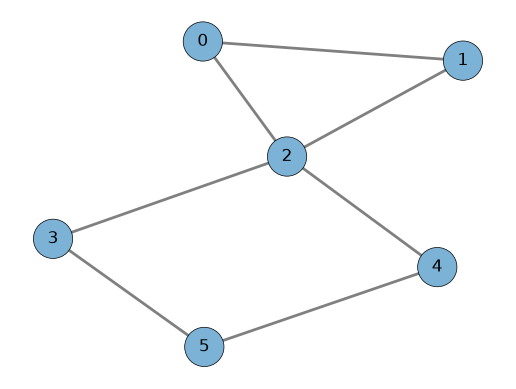

In [24]:
G = nx.Graph()
graph_edges = [[0,1],[0,2],[1,2],[2,3],[2,4],[3,5],[4,5]]
G.add_edges_from(graph_edges)

MaxCut_instance = MaxCutInstance(G)
MaxCut_instance.draw_problem()

In [25]:
layers = 2
parameter_guesses = [0.1, 0.2, 0.1, 0.2]

MaxCut_qaoa = QUBOQAOA(problem=MaxCut_instance,
                       num_layers=layers,
                       initial_angles=parameter_guesses)
MaxCut_qaoa.train()

In [26]:
qiskit_qc = qiskit_circuit(MaxCut_qaoa, measurements=True)
qrispqc = QuantumCircuit.from_qiskit(qiskit_qc)
print(qrispqc)

        ┌───┐┌───────┐                            ┌────────────┐  ┌───────┐   »
   q.0: ┤ H ├┤ Rz(0) ├─■─────────────■────────────┤ Rx(1.0966) ├──┤ Rz(0) ├───»
        ├───┤├───────┤ │ZZ(-0.6086)  │            └────────────┘┌─┴───────┴──┐»
   q.1: ┤ H ├┤ Rz(0) ├─■─────────────┼─────────────■────────────┤ Rx(1.0966) ├»
        ├───┤├───────┤               │ZZ(-0.6086)  │ZZ(-0.6086) └────────────┘»
   q.2: ┤ H ├┤ Rz(0) ├───────────────■─────────────■─────────────■────────────»
        ├───┤├───────┤                                           │ZZ(-0.6086) »
   q.3: ┤ H ├┤ Rz(0) ├───────────────────────────────────────────■────────────»
        ├───┤├───────┤                                                        »
   q.4: ┤ H ├┤ Rz(0) ├────────────────────────────────────────────────────────»
        ├───┤├───────┤                                                        »
   q.5: ┤ H ├┤ Rz(0) ├────────────────────────────────────────────────────────»
        └───┘└───────┘                  

In [27]:
samples = qrispqc.run(backend=iqm_device, shots=2000)
print(samples)

most_probable = max(samples, key=lambda y: samples[y])
most_probable_cost = MaxCut_instance.quality(most_probable)
print("Cost of most probable outcome: ", most_probable_cost)
print("Most probable outcome :", most_probable)

{'000000': 7, '100000': 23, '010000': 12, '110000': 9, '001000': 1, '101000': 10, '011000': 32, '111000': 3, '000100': 42, '100100': 275, '010100': 25, '110100': 24, '001100': 7, '101100': 15, '011100': 27, '000010': 3, '100010': 17, '010010': 18, '110010': 18, '001010': 8, '101010': 5, '011010': 128, '111010': 7, '000110': 11, '100110': 146, '010110': 25, '110110': 9, '001110': 14, '101110': 9, '011110': 21, '111110': 6, '000001': 8, '100001': 40, '010001': 20, '110001': 18, '001001': 19, '101001': 6, '011001': 184, '111001': 10, '000101': 15, '100101': 181, '010101': 22, '110101': 13, '001101': 22, '101101': 9, '011101': 22, '111101': 1, '000011': 4, '100011': 28, '010011': 27, '110011': 14, '001011': 25, '101011': 12, '011011': 238, '111011': 15, '000111': 12, '100111': 41, '010111': 6, '110111': 5, '001111': 7, '101111': 6, '011111': 11, '111111': 2}
Cost of most probable outcome:  -4.0
Most probable outcome : 100100


In [28]:
print("Optimal cost: ", MaxCut_instance.lower_bound)

samples_cost = {sample: MaxCut_instance.quality(sample) for sample in samples}
best_sample = min(samples_cost, key=lambda y: samples_cost[y])
best_quality = samples_cost[best_sample]

print("Best sample found by QAOA: ", best_sample)
print("Best cost found by QAOA: ", best_quality)

Optimal cost:  -6.0
Best sample found by QAOA:  100110
Best cost found by QAOA:  -6.0


In [29]:
layers = 4
parameter_guesses = [0.1, 0.2] * layers

MaxCut_qaoa_4 = QUBOQAOA(problem=MaxCut_instance,
                         num_layers=layers,
                         initial_angles=parameter_guesses)
MaxCut_qaoa_4.train()

qiskit_qc4 = qiskit_circuit(MaxCut_qaoa_4, measurements=True)
qrispqc4 = QuantumCircuit.from_qiskit(qiskit_qc4)
samples4 = qrispqc4.run(backend=iqm_device, shots=2000)

most_probable4 = max(samples4, key=lambda y: samples4[y])
print("Most probable:", most_probable4, MaxCut_instance.quality(most_probable4))

Most probable: 011001 -6.0


In [30]:
!pip install -q pylatexenc

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from iqm.qrisp_iqm import IQMBackend, create_iqm_pass_manager
from qrisp import QuantumVariable, h, p, cx, manual_layout, measure, barrier
from rustworkx import spring_layout, PyGraph
from rustworkx.visualization import mpl_draw
print("ok")

ok


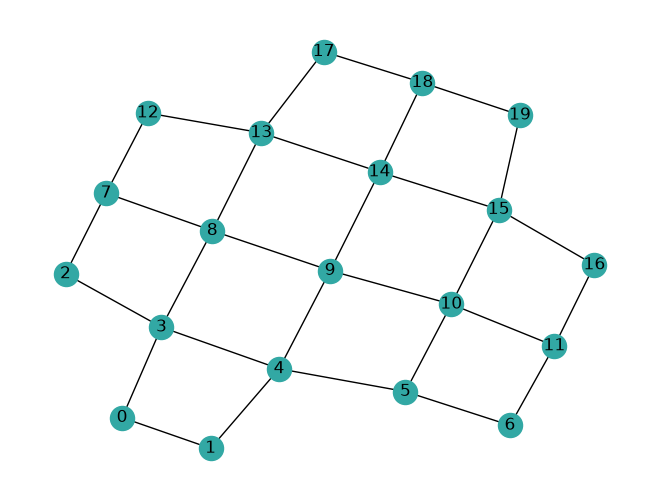

In [32]:
connectivity = iqm_device.connectivity
graph = PyGraph()
graph.extend_from_edge_list(connectivity)

mpl_draw(graph, arrows=False, with_labels=True, node_color='#32a8a4',
         pos=spring_layout(graph, num_iter=200))

In [33]:
num_qb = 3
qv = QuantumVariable(num_qb)
h(qv[0])
for qb in range(1, num_qb):
    cx(qv[0], qv[qb])
measure(qv)
print(qv.qs)

QuantumCircuit:
---------------
        ┌───┐             ┌─┐   
  qv.0: ┤ H ├──■────■─────┤M├───
        └───┘┌─┴─┐  │  ┌─┐└╥┘   
  qv.1: ─────┤ X ├──┼──┤M├─╫────
             └───┘┌─┴─┐└╥┘ ║ ┌─┐
  qv.2: ──────────┤ X ├─╫──╫─┤M├
                  └───┘ ║  ║ └╥┘
cb_179: ════════════════╬══╩══╬═
                        ║     ║ 
cb_180: ════════════════╩═════╬═
                              ║ 
cb_181: ══════════════════════╩═
                                
Live QuantumVariables:
----------------------
QuantumVariable qv


In [34]:
manual_qubits_1 = [0, 1, 4]
manual_qubits_2 = [13, 14, 17]

reduced_coupling_1 = [pair for pair in connectivity if pair[0] in manual_qubits_1 and pair[1] in manual_qubits_1]
reduced_coupling_2 = [pair for pair in connectivity if pair[0] in manual_qubits_2 and pair[1] in manual_qubits_2]
print("Reduced coupling map, set 1: ", reduced_coupling_1)
print("Reduced coupling map, set 2: ", reduced_coupling_2)

Reduced coupling map, set 1:  [(1, 0), (1, 4)]
Reduced coupling map, set 2:  [(13, 14), (13, 17)]


In [35]:
pm_1 = create_iqm_pass_manager(iqm_device.connectivity)
pm_2 = create_iqm_pass_manager(iqm_device.connectivity)

pm_1.remove_pass(7)
pm_2.remove_pass(7)

pm_1.insert_pass(0, manual_layout(manual_qubits_1))
pm_2.insert_pass(0, manual_layout(manual_qubits_2))

qc1_transpiled = pm_1.run(qv.qs)
qc2_transpiled = pm_2.run(qv.qs)
print(qc1_transpiled)
print(qc2_transpiled)

              ┌─────────────┐                       ┌─┐   
        qv.0: ┤ R(π/2,-π/2) ├─■──■──────────────────┤M├───
              ├─────────────┤ │  │ ┌────────────┐┌─┐└╥┘   
        qv.1: ┤ R(π/2,-π/2) ├─■──┼─┤ R(π/2,π/2) ├┤M├─╫────
              └─────────────┘    │ └────────────┘└╥┘ ║    
amended_qb_0: ───────────────────┼────────────────╫──╫────
              ┌─────────────┐    │ ┌────────────┐ ║  ║ ┌─┐
amended_qb_1: ┤ R(π/2,-π/2) ├────■─┤ R(π/2,π/2) ├─╫──╫─┤M├
              └─────────────┘      └────────────┘ ║  ║ └╥┘
        qv.2: ────────────────────────────────────╫──╫──╫─
                                                  ║  ║  ║ 
      qb_678: ────────────────────────────────────╫──╫──╫─
                                                  ║  ║  ║ 
      qb_679: ────────────────────────────────────╫──╫──╫─
                                                  ║  ║  ║ 
      qb_680: ────────────────────────────────────╫──╫──╫─
                                                  ║  ║  

{'000': 519, '100': 11, '010': 11, '110': 6, '001': 3, '101': 13, '011': 19, '111': 418}


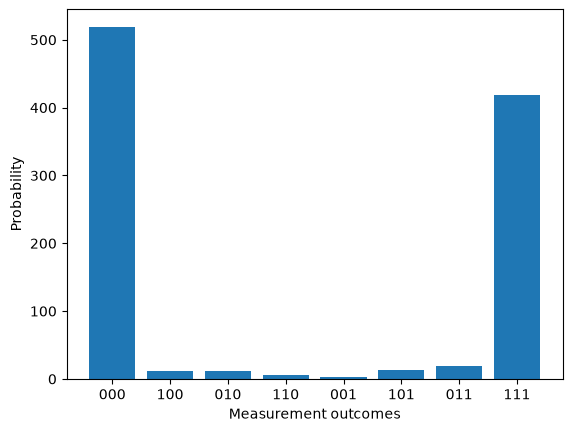

In [36]:
shots = 1000
job1 = qc1_transpiled.run(backend=iqm_device, shots=shots)
print(job1)

plt.bar(list(map(str, job1.keys())), job1.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

{'000': 465, '100': 8, '010': 10, '110': 7, '001': 3, '101': 25, '011': 11, '111': 471}


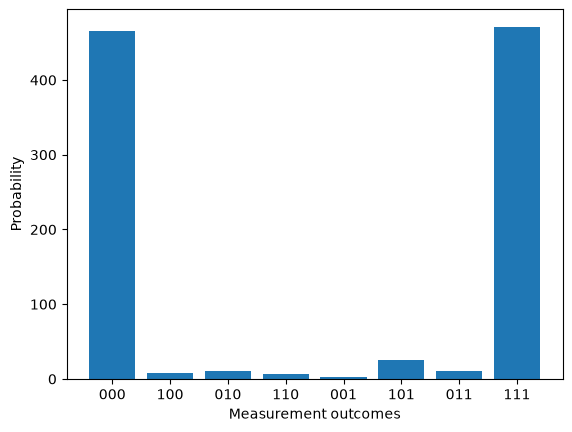

In [37]:
shots = 1000
job2 = qc2_transpiled.run(backend=iqm_device, shots=shots)
print(job2)

plt.bar(list(map(str, job2.keys())), job2.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Probability")
plt.show()

In [38]:
num_qb = 9
big_GHZ = QuantumVariable(num_qb)

h(big_GHZ[0])
for qb in range(1, num_qb):
    cx(big_GHZ[0], big_GHZ[qb])

barrier(big_GHZ)
measure(big_GHZ)
print(big_GHZ.qs)

QuantumCircuit:
---------------
           ┌───┐                                         ░ ┌─┐               »
big_GHZ.0: ┤ H ├──■────■────■────■────■────■────■────■───░─┤M├───────────────»
           └───┘┌─┴─┐  │    │    │    │    │    │    │   ░ └╥┘┌─┐            »
big_GHZ.1: ─────┤ X ├──┼────┼────┼────┼────┼────┼────┼───░──╫─┤M├────────────»
                └───┘┌─┴─┐  │    │    │    │    │    │   ░  ║ └╥┘┌─┐         »
big_GHZ.2: ──────────┤ X ├──┼────┼────┼────┼────┼────┼───░──╫──╫─┤M├─────────»
                     └───┘┌─┴─┐  │    │    │    │    │   ░  ║  ║ └╥┘┌─┐      »
big_GHZ.3: ───────────────┤ X ├──┼────┼────┼────┼────┼───░──╫──╫──╫─┤M├──────»
                          └───┘┌─┴─┐  │    │    │    │   ░  ║  ║  ║ └╥┘┌─┐   »
big_GHZ.4: ────────────────────┤ X ├──┼────┼────┼────┼───░──╫──╫──╫──╫─┤M├───»
                               └───┘┌─┴─┐  │    │    │   ░  ║  ║  ║  ║ └╥┘┌─┐»
big_GHZ.5: ─────────────────────────┤ X ├──┼────┼────┼───░──╫──╫──╫──╫──╫─┤M├»
                    

In [39]:
efficient_GHZ = QuantumVariable(9)

h(efficient_GHZ[0])
cx(efficient_GHZ[0], efficient_GHZ[1])
cx(efficient_GHZ[0], efficient_GHZ[2])
cx(efficient_GHZ[0], efficient_GHZ[3])
cx(efficient_GHZ[0], efficient_GHZ[4])
cx(efficient_GHZ[1], efficient_GHZ[5])
cx(efficient_GHZ[2], efficient_GHZ[6])
cx(efficient_GHZ[3], efficient_GHZ[7])
cx(efficient_GHZ[4], efficient_GHZ[8])

barrier(efficient_GHZ)
measure(efficient_GHZ)

my_nine_qubits = [9, 4, 8, 10, 14, 1, 7, 5, 13]

print(efficient_GHZ.qs)

QuantumCircuit:
---------------
                 ┌───┐                                         ░ ┌─┐         »
efficient_GHZ.0: ┤ H ├──■────■─────────■─────────■─────────────░─┤M├─────────»
                 └───┘┌─┴─┐  │         │         │             ░ └╥┘┌─┐      »
efficient_GHZ.1: ─────┤ X ├──┼────■────┼─────────┼─────────────░──╫─┤M├──────»
                      └───┘┌─┴─┐  │    │         │             ░  ║ └╥┘┌─┐   »
efficient_GHZ.2: ──────────┤ X ├──┼────┼────■────┼─────────────░──╫──╫─┤M├───»
                           └───┘  │  ┌─┴─┐  │    │             ░  ║  ║ └╥┘┌─┐»
efficient_GHZ.3: ─────────────────┼──┤ X ├──┼────┼────■────────░──╫──╫──╫─┤M├»
                                  │  └───┘  │  ┌─┴─┐  │        ░  ║  ║  ║ └╥┘»
efficient_GHZ.4: ─────────────────┼─────────┼──┤ X ├──┼────■───░──╫──╫──╫──╫─»
                                ┌─┴─┐       │  └───┘  │    │   ░  ║  ║  ║  ║ »
efficient_GHZ.5: ───────────────┤ X ├───────┼─────────┼────┼───░──╫──╫──╫──╫─»
                    

In [40]:
pm = create_iqm_pass_manager(iqm_device.connectivity)
pm.remove_pass(7)
pm.insert_pass(0, manual_layout(my_nine_qubits))

inefficient_transpiled = pm.run(big_GHZ.qs)
efficient_transpiled = pm.run(efficient_GHZ.qs)
print("transpiled")

transpiled


In [41]:
def count_2q(qc):
    return sum(1 for instr in qc.data if len(instr.qubits) == 2)

print("Inefficient 2-qubit gates:", count_2q(inefficient_transpiled))
print("Efficient   2-qubit gates:", count_2q(efficient_transpiled))
print("Inefficient depth:", inefficient_transpiled.depth())
print("Efficient   depth:", efficient_transpiled.depth())

Inefficient 2-qubit gates: 16
Efficient   2-qubit gates: 8
Inefficient depth: 13
Efficient   depth: 10


Inefficient — 000000000: 822  111111111: 616  total: 0.719


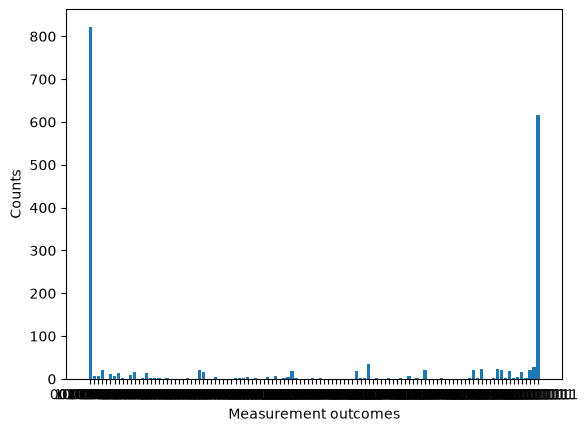

In [42]:
shots = 2000
inefficient_job = inefficient_transpiled.run(backend=iqm_device, shots=shots)

zeros = inefficient_job.get('0'*9, 0)
ones = inefficient_job.get('1'*9, 0)
print("Inefficient — 000000000:", zeros, " 111111111:", ones, " total:", (zeros+ones)/shots)

plt.bar(list(map(str, inefficient_job.keys())), inefficient_job.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Counts")
plt.show()

Efficient — 000000000: 869  111111111: 704  total: 0.7865


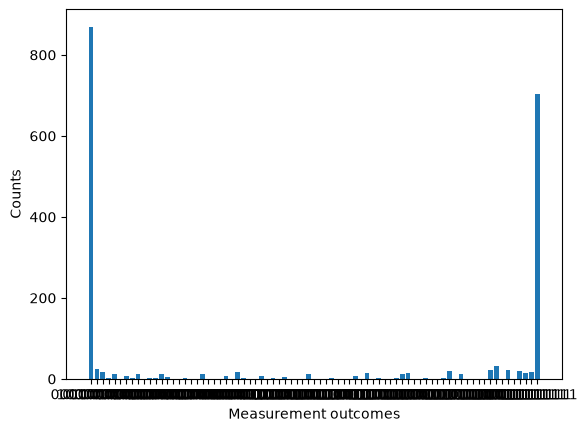

In [43]:
efficient_job = efficient_transpiled.run(backend=iqm_device, shots=shots)

zeros = efficient_job.get('0'*9, 0)
ones = efficient_job.get('1'*9, 0)
print("Efficient — 000000000:", zeros, " 111111111:", ones, " total:", (zeros+ones)/shots)

plt.bar(list(map(str, efficient_job.keys())), efficient_job.values())
plt.xlabel("Measurement outcomes")
plt.ylabel("Counts")
plt.show()

In [44]:
import sys
if 'google.colab' in sys.modules:
    !pip list --format=freeze | grep -iE '^(google-colab|ipykernel|jupyter-core)=' > /content/colab-pins.txt
    !pip install -c /content/colab-pins.txt "iqm-pulla[pin-iqm]==14.0.0" ipython==8.21.0 "qrisp[iqm]==0.9.6"
else:
    !pip install iqm-pulla "qrisp[iqm]"

  Using cached iqm_data_definitions-2.24-py3-none-any.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.0/810.0 kB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.1 MB/s  0:00:00
Using cached iqm_data_definitions-2.24-py3-none-any.whl (80 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 156.0 MB/s  0:00:00
  Attempting uninstall: parso
    Found existing installation: parso 0.8.5
    Uninstalling parso-0.8.5:
      Successfully uninstalled parso-0.8.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
  Attempting uninstall: qrisp
    Found existing installation: qrisp 0.9.7
    Uninstalling qrisp-0.9.7:
      Successfully uninstalled qrisp-0.9.7
  Attempting uninstall: iqm-data-definitions
    Found existing installation: iqm-data-definitions 3.0
    Uninstalling iqm-data-definitions-3.0:
      Successfully uninstalled iq

In [1]:
import os, getpass
from iqm.pulla.pulla import Pulla

if not os.environ.get("IQM_TOKEN"):
    os.environ["IQM_TOKEN"] = getpass.getpass("IQM Resonance token: ")

os.environ["IQM_SERVER_URL"] = "https://resonance.iqm.tech"
iqm_server_url = os.environ["IQM_SERVER_URL"]

p = Pulla(iqm_server_url, quantum_computer="garnet")
compiler = p.get_standard_compiler()
print("compiler ready")

IQM Resonance token: ··········
compiler ready


In [2]:
from qrisp import QuantumVariable, h, cx

qv = QuantumVariable(3)
h(qv[0])
cx(qv[0], qv[1])
cx(qv[0], qv[2])
qv.get_measurement()

qc_0 = qv.qs
print(qc_0)

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.3 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


QuantumCircuit:
---------------
      ┌───┐          
qv.0: ┤ H ├──■────■──
      └───┘┌─┴─┐  │  
qv.1: ─────┤ X ├──┼──
           └───┘┌─┴─┐
qv.2: ──────────┤ X ├
                └───┘
Live QuantumVariables:
----------------------
QuantumVariable qv


In [3]:
from iqm.qrisp_iqm import transpile_to_iqm, IQMBackend

os.environ['IQM_SERVER_URL'] = "https://resonance.iqm.tech"
backend = IQMBackend(device_instance="garnet")

coupling_map = backend.connectivity
transpiled_qc = transpile_to_iqm(qc_0, coupling_map)
print(transpiled_qc)

               ┌─────────────┐                    
         qv.0: ┤ R(π/2,-π/2) ├─■──■───────────────
               ├─────────────┤ │  │ ┌────────────┐
         qv.1: ┤ R(π/2,-π/2) ├─■──┼─┤ R(π/2,π/2) ├
               └─────────────┘    │ └────────────┘
 amended_qb_0: ───────────────────┼───────────────
               ┌─────────────┐    │ ┌────────────┐
         qv.2: ┤ R(π/2,-π/2) ├────■─┤ R(π/2,π/2) ├
               └─────────────┘      └────────────┘
 amended_qb_1: ───────────────────────────────────
                                                  
 amended_qb_2: ───────────────────────────────────
                                                  
 amended_qb_3: ───────────────────────────────────
                                                  
 amended_qb_4: ───────────────────────────────────
                                                  
 amended_qb_5: ───────────────────────────────────
                                                  
 amended_qb_6: ────────────────

In [4]:
from iqm.iqm_client import IQMClient
from iqm.qrisp_iqm import qrisp_to_iqm_converter

client = IQMClient(quantum_computer="garnet")
dqa = client.get_dynamic_quantum_architecture()
iqm_circuit = qrisp_to_iqm_converter(transpiled_qc, dqa)
job_definition, context = compiler.compile([iqm_circuit])
print("compiled")

compiled


In [5]:
from iqm.pulse.playlist.visualisation.base import inspect_playlist
from IPython.display import HTML, display

html_content = inspect_playlist(job_definition.sweep_definition.playlist)
display(HTML(html_content))

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [2]:

%%capture
import sys
if 'google.colab' in sys.modules:
    !pip install --upgrade pip
    !pip install --force-reinstall --no-cache-dir iqm-pulla[notebook-pin-all]
    !pip install --force-reinstall --no-cache-dir "numpy==2.3.4" "scipy>=1.14,<1.17"
else:
    !pip install iqm-pulla

In [3]:
import os, getpass
from iqm.pulla.pulla import Pulla

if not os.environ.get("IQM_TOKEN"):
    os.environ["IQM_TOKEN"] = getpass.getpass("IQM Resonance token: ")

iqm_server_url = os.environ.get("IQM_SERVER_URL", "https://resonance.iqm.tech")
p = Pulla(iqm_server_url, quantum_computer="garnet")
compiler = p.get_standard_compiler()
print("ready")

ImportError: cannot import name '_slice' from 'numpy._core.umath' (/usr/local/lib/python3.13/dist-packages/numpy/_core/umath.py)

In [4]:
!pip uninstall -y numpy
!pip install --no-cache-dir "numpy==2.3.4"

Found existing installation: numpy 2.3.4
Uninstalling numpy-2.3.4:
  Successfully uninstalled numpy-2.3.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 288.4 MB/s  0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.4 which is incompatible.


In [1]:
import numpy
print(numpy.__version__)

2.3.4


In [2]:
import os, getpass
from iqm.pulla.pulla import Pulla

if not os.environ.get("IQM_TOKEN"):
    os.environ["IQM_TOKEN"] = getpass.getpass("IQM Resonance token: ")

iqm_server_url = os.environ.get("IQM_SERVER_URL", "https://resonance.iqm.tech")
p = Pulla(iqm_server_url, quantum_computer="garnet")
compiler = p.get_standard_compiler()
print("ready")

IQM Resonance token: ··········
ready


In [3]:
from iqm.pulse import Circuit
from iqm.pulse import CircuitOperation as Op
import numpy as np

qubit = "QB1"
circuits = []
for name, angle in zip(["state0", "state1", "superposition"], [0.0, np.pi, np.pi/2]):
    circuit = Circuit(name, [
        Op("prx", (qubit,), args={"angle": angle, "phase": 0.0}),
        Op("measure_fidelity", (qubit,), args={"key": "M"})
    ])
    circuits.append(circuit)
print(len(circuits), "circuits")

3 circuits


In [4]:
settings = compiler.get_settings(circuits)
settings.get_gate_node_for_locus("measure_fidelity", qubit).acquisition_type = "complex"
print("acquisition_type set to complex")

acquisition_type set to complex


In [5]:
job_definition, context = compiler.compile(circuits, settings=settings)
job = p.submit_playlist(job_definition, context=context)
job.wait_for_completion()

InvalidOperationError: Personal account does not have pulse-level access enabled required to submit this job

In [6]:
import traceback
try:
    job = p.submit_playlist(job_definition, context=context)
    job.wait_for_completion()
except Exception as e:
    print(type(e).__name__)
    print(e)
    traceback.print_exc()

InvalidOperationError
Personal account does not have pulse-level access enabled required to submit this job


Traceback (most recent call last):
  File "/tmp/ipykernel_7536/1346447088.py", line 3, in <module>
    job = p.submit_playlist(job_definition, context=context)
  File "/usr/local/lib/python3.13/dist-packages/iqm/pulla/pulla.py", line 198, in submit_playlist
    job_data = self._iqm_server_client.submit_run(run_definition, use_timeslot=use_timeslot)
  File "/usr/local/lib/python3.13/dist-packages/iqm/iqm_server_client/iqm_server_client.py", line 351, in submit_run
    return self._submit_job(job_type="run", protobuf_data=data, use_timeslot=use_timeslot)
           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/iqm/iqm_server_client/iqm_server_client.py", line 430, in _submit_job
    response = self._send_request(
        requests.post,
    ...<3 lines>...
        protobuf_data=protobuf_data,
    )
  File "/usr/local/lib/python3.13/dist-packages/iqm/iqm_server_client/iqm_server_client.py", line 604, in _send